In [1]:
import rebound as rb
import reboundx
from reboundx import constants as rbx_constants
import numpy as np
from celmech.miscellaneous import frequency_modified_fourier_transform as fmft
import celmech as cm
import assist
import sys
sys.path.insert(0, "..")
import utils

from matplotlib import pyplot as plt

Searching NASA Horizons for 'sun'... 
Found: Sun (10) 


In [2]:
# used for getting fmft result closest to target frequency
def closest_key_entry(d, target):
    """
    Given a dictionary `d` with float keys and a target float `target`,
    returns a tuple (key, value) where the key is the one in `d`
    closest to `target`.

    Parameters
    ----------
    d : dict
        Dictionary with float keys.
    target : float
        The float to compare keys against.

    Returns
    -------
    tuple
        The (key, value) pair whose key is closest to `target`.
    """
    closest_key = min(d.keys(), key=lambda k: abs(k - target))
    return closest_key, d[closest_key]


In [3]:
import pandas as pd

df_xgb = pd.read_csv("data/model_results.csv", index_col=0)

# Outer solar system synthetic secular theory
This notebook uses a numerical integration and the frequency modified Fourier transform to generate a synthetic secular theory for the outer solar system planets.

In [4]:
start_time = 2460200.5
planets = ("Jupiter","Saturn","Uranus","Neptune")

In [5]:
asteroids_bad = ("K17C40J", "K17P13T", "K15XE4D")
asteroids_good = ("K19UE3G", "K19N69E")

In [6]:
asteroids = asteroids_bad + asteroids_good

In [7]:
test_particles = [
    {"name": "test_1", "a": 1.2, "e": 0.01, "inc": 1.0, "Omega": 0.0, "omega": 0.0, "M": 0.0},
    {"name": "test_2", "a": 1.5, "e": 0.01, "inc": 1.0, "Omega": 30.0, "omega": 20.0, "M": 60.0},
    {"name": "test_3", "a": 1.8, "e": 0.02, "inc": 2.0, "Omega": 60.0, "omega": 40.0, "M": 120.0},
]

test_particle_names = [p["name"] for p in test_particles]

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for 'K17C40J'... 
Found: (2017 CJ40) 
Searching NASA Horizons for 'K17P13T'... 


/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: (2017 PT13) 
Searching NASA Horizons for 'K15XE4D'... 
Found: (2015 XD144) 
Searching NASA Horizons for 'K19UE3G'... 
Found: (2019 UG143) 
Searching NASA Horizons for 'K19N69E'... 
Found: (2019 NE69) 


/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: REBOUNDx: Passing a velocity-dependent force to WHFAST. Need to apply as an operator. See REBOUNDx paper sec 5.1.
  warnings.warn(msg[1:], RuntimeWarning)
/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/home/kdey/proper_elements_prediction/.venv/lib/python3.12/site-packages/rebound/simulationarchive.py:155: RuntimeWarning: The simulation might not be synchronized. You can manually synchronize it by calling sim.synchronize().
  warnings.warn("The simulation might not be synchronized. You can manually synchronize it by calling sim.synchronize().", RuntimeWarning)


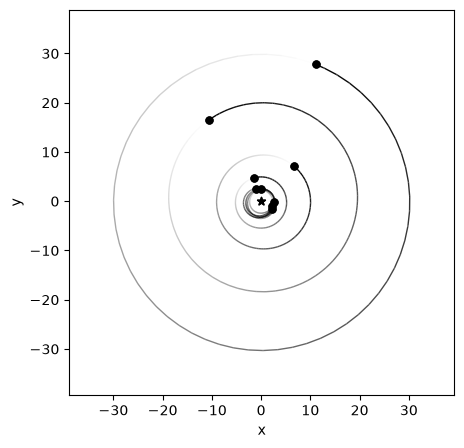

In [8]:
sim = rb.Simulation()

rebx = reboundx.Extras(sim)
gr = rebx.load_force("gr")
rebx.add_force(gr)
gr.params['c'] = rbx_constants.C

sim.add("Sun", date="JD%f"%start_time)
sim.add("Jupiter", date="JD%f"%start_time)
sim.add("Saturn", date="JD%f"%start_time)
sim.add("Uranus", date="JD%f"%start_time)
sim.add("Neptune", date="JD%f"%start_time)

for asteroid in asteroids:
    sim.add(asteroid, date="JD%f"%start_time)
    sim.particles[-1].m = 0

# for p in test_particles:
#     sim.add(
#         hash=p["name"],
#         m=0,
#         a=p["a"],
#         e=p["e"],
#         inc=np.radians(p["inc"]),
#         Omega=np.radians(p["Omega"]),
#         omega=np.radians(p["omega"]),
#         M=np.radians(p["M"]),
#         primary=sim.particles[0],
#     )
sim.move_to_com()

# Save initial orbital elements
rows = []

for j, asteroid in enumerate(asteroids):
    p = sim.particles[5 + j]
    orb = p.orbit(primary=sim.particles[0])
    rows.append({
        "name": asteroid,
        "type": "real asteroid",
        "a": orb.a,
        "e": orb.e,
        "Incl.": np.degrees(orb.inc),
        "Node": np.degrees(orb.Omega),
        "Peri.": np.degrees(orb.omega),
    })

# for p_info in test_particles:
#     name = p_info["name"]
#     orb = sim.particles[name].orbit(primary=sim.particles[0])
#     rows.append({
#         "name": name,
#         "type": "test particle",
#         "a": orb.a,
#         "e": orb.e,
#         "a": orb.a,
#         "e": orb.e,
#         "Incl.": np.degrees(orb.inc),
#         "Node": np.degrees(orb.Omega),
#         "Peri.": np.degrees(orb.omega),
#     })

df_orbits = pd.DataFrame(rows)

# Integration
cm.nbody_simulation_utilities.align_simulation(sim)
rb.OrbitPlot(sim)

sim.integrator = 'whfast'
sim.dt = sim.particles[1].P / 25.
sim.ri_whfast.safe_mode = 0
Tfin_approx = 1e7 * 2*np.pi
total_steps = np.ceil(Tfin_approx / sim.dt)
Tfin = total_steps * sim.dt + sim.dt
Nout = 8192
sim.save_to_file("testing.sa",step=int(np.floor(total_steps/Nout)),delete_file=True)
sim.integrate(Tfin,exact_finish_time=0)
results = cm.nbody_simulation_utilities.get_simarchive_integration_results("testing.sa",coordinates='heliocentric')

In [9]:
results['X'] = np.sqrt(2*(1-np.sqrt(1-results['e']**2))) * np.exp(1j * results['pomega'])
results['Y'] = (1-results['e']**2)**(0.25) * np.sin(0.5 * results['inc'] )* np.exp(1j * results['Omega'])

In [10]:
planets = ("Jupiter","Saturn","Uranus","Neptune") + asteroids #+ test_particle_names
ecc_fmft_results = dict()
inc_fmft_results = dict()
for i,pl in enumerate(planets):
    ecc_fmft_results[pl] = fmft(results['time'],results['X'][i],14)
    planet_e_freqs = np.array(list(ecc_fmft_results[pl].keys()))
    planet_e_freqs_arcsec_per_yr = planet_e_freqs * 60*60*180/np.pi * (2*np.pi)

    inc_fmft_results[pl] = fmft(results['time'],results['Y'][i],8)
    planet_inc_freqs = np.array(list(inc_fmft_results[pl].keys()))
    planet_inc_freqs_arcsec_per_yr = planet_inc_freqs * 60*60*180/np.pi * (2*np.pi)

    print("")
    print(pl)
    print("g")
    print("-------")
    for g in planet_e_freqs[:6]:
        print("{:+07.3f} \t {:0.6f} \t {:0.3f}".format(g * 60 * 60 * 180 / np.pi * (2 * np.pi), np.abs(ecc_fmft_results[pl][g]), np.angle(ecc_fmft_results[pl][g])))
    print("s")
    print("-------")
    for g in planet_inc_freqs[:4]:
        print("{:+07.3f} \t {:0.6f} \t {:0.3f}".format(g * 60 * 60 * 180 / np.pi * (2 * np.pi), np.abs(inc_fmft_results[pl][g]), np.angle(inc_fmft_results[pl][g])))


Jupiter
g
-------
+04.246 	 0.044206 	 1.821
+28.241 	 0.015694 	 0.516
+03.089 	 0.001843 	 -2.908
-30.978 	 0.000642 	 0.530
+52.237 	 0.000571 	 2.355
+464.193 	 0.000396 	 0.632
s
-------
-26.338 	 0.003150 	 0.184
-00.692 	 0.000574 	 1.693
-02.994 	 0.000485 	 -2.577
-26.989 	 0.000023 	 -1.283

Saturn
g
-------
+28.241 	 0.048225 	 -2.626
+04.246 	 0.032965 	 1.821
+52.237 	 0.001925 	 -0.786
+03.089 	 0.001533 	 -2.908
+345.753 	 0.001510 	 -2.519
+464.193 	 0.001246 	 -2.511
s
-------
-26.338 	 0.007853 	 -2.958
-00.692 	 0.000553 	 1.693
-02.994 	 0.000394 	 -2.577
-26.989 	 0.000060 	 1.860

Uranus
g
-------
+04.246 	 0.038084 	 -1.320
+03.089 	 0.029027 	 -2.907
+305.323 	 0.002078 	 -0.982
+00.672 	 0.001663 	 2.595
+28.241 	 0.001549 	 0.516
-501.336 	 0.001350 	 -0.850
s
-------
-02.994 	 0.008897 	 0.558
-00.692 	 0.000555 	 -1.461
-26.338 	 0.000354 	 0.184
-02.342 	 0.000298 	 -1.119

Neptune
g
-------
+00.673 	 0.009122 	 2.568
+03.089 	 0.003707 	 0.233
+04.246 	 0

(0.0, 10000000.0)

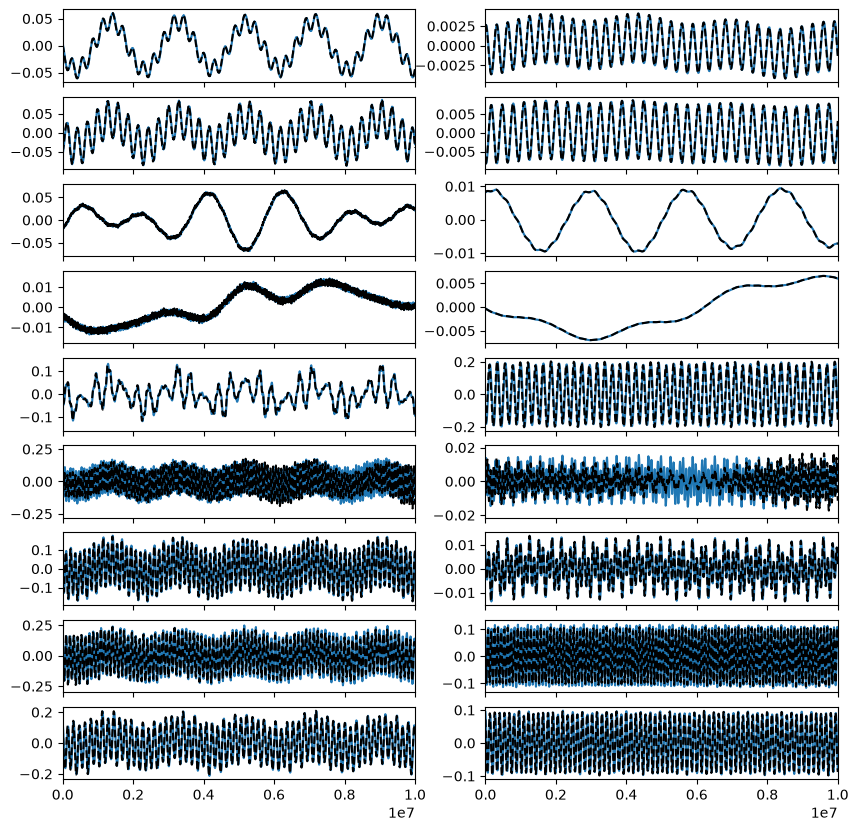

In [11]:
fig,ax = plt.subplots(sim.N-1,2,sharex=True,figsize=(10,10))
Xsolns = []
Ysolns = []
for i,pl in enumerate(planets):
    freq_amp_dict = ecc_fmft_results[pl]
    ax[i,0].plot(results['time'],np.real(results['X'][i]))
    zsoln = np.sum([amp * np.exp(1j*freq*results['time']) for freq,amp in freq_amp_dict.items()],axis=0)
    ax[i,0].plot(results['time'],np.real(zsoln),'k--')

    freq_amp_dict = inc_fmft_results[pl]
    Ysolns.append(freq_amp_dict)
    ax[i,1].plot(results['time'],np.real(results['Y'][i]))
    zsoln = np.sum([amp * np.exp(1j*freq*results['time']) for freq,amp in freq_amp_dict.items()],axis=0)
    ax[i,1].plot(results['time'],np.real(zsoln),'k--')
plt.xlim(0,1e7)

In [12]:
ARCSEC_PER_YR = 1/(180*60*60*2)
g_vec = np.zeros(4)
s_vec = np.zeros(3)

g_vec[:3] = np.array(list(ecc_fmft_results['Jupiter'].keys()))[:3]
g_vec[3] = list(ecc_fmft_results['Neptune'].keys())[0]
s_vec[0] = list(inc_fmft_results['Jupiter'].keys())[0]
s_vec[1] = list(inc_fmft_results['Jupiter'].keys())[2]
s_vec[2] = list(inc_fmft_results['Jupiter'].keys())[1]
omega_vec = np.concatenate((g_vec,s_vec))
g_and_s_arc_sec_per_yr = omega_vec / ARCSEC_PER_YR
g_and_s_arc_sec_per_yr

array([  4.24552786,  28.24136038,   3.089066  ,   0.67272162,
       -26.33761107,  -2.99375035,  -0.69243627])

In [13]:
eye_N = np.eye(omega_vec.size,dtype = int)
x_dicts = []
for pl in planets:
    print(pl)    
    print("-"*len(pl))
    print("kvec \t\t\t omega \t err. \t amplitude")
    x_dict = {}
    for i,omega_i in enumerate(omega_vec[:4]):
        omega_N,amp = closest_key_entry(ecc_fmft_results[pl],omega_vec[i])
        omega_error = np.abs(omega_N/omega_i-1)
        if omega_error<0.001:
            print (eye_N[i],"\t{:+07.3f}\t{:.1g} \t{:.1g}".format(omega_i/ARCSEC_PER_YR,omega_error,np.abs(amp)))
            x_dict[tuple(eye_N[i])] = amp
    #NL terms
    for a in range(7):
        for b in range(a,7):
            for c in range(7):
                if c==a:
                    continue
                if c==b:
                    continue
                k = np.zeros(7,dtype = int)
                k[a] +=1
                k[b] +=1
                k[c] -=1
                omega=k@omega_vec
                omega_N,amp = closest_key_entry(ecc_fmft_results[pl],omega)
                omega_error = np.abs(omega_N/omega-1)
                if omega_error<0.001:
                    print (k,"\t{:+07.3f}\t{:.1g},\t{:.1g}".format(omega/ARCSEC_PER_YR,omega_error,np.abs(amp)))
                    x_dict[tuple(k)] = amp
    x_dicts.append(x_dict)

Jupiter
-------
kvec 			 omega 	 err. 	 amplitude
[1 0 0 0 0 0 0] 	+04.246	0 	0.04
[0 1 0 0 0 0 0] 	+28.241	0 	0.02
[0 0 1 0 0 0 0] 	+03.089	0 	0.002
[ 1  1 -1  0  0  0  0] 	+29.398	2e-07,	0.0002
[ 1  0  0  0 -1  1  0] 	+27.589	0.0001,	0.0001
[-1  2  0  0  0  0  0] 	+52.237	2e-06,	0.0006
[-1  1  1  0  0  0  0] 	+27.085	3e-06,	0.0002
Saturn
------
kvec 			 omega 	 err. 	 amplitude
[1 0 0 0 0 0 0] 	+04.246	4e-07 	0.03
[0 1 0 0 0 0 0] 	+28.241	2e-08 	0.05
[0 0 1 0 0 0 0] 	+03.089	5e-08 	0.002
[ 1  1 -1  0  0  0  0] 	+29.398	1e-07,	0.0006
[ 1  0  0  0 -1  1  0] 	+27.589	0.0001,	0.0003
[-1  2  0  0  0  0  0] 	+52.237	3e-06,	0.002
[-1  1  1  0  0  0  0] 	+27.085	2e-06,	0.0006
Uranus
------
kvec 			 omega 	 err. 	 amplitude
[1 0 0 0 0 0 0] 	+04.246	3e-08 	0.04
[0 1 0 0 0 0 0] 	+28.241	1e-07 	0.002
[0 0 1 0 0 0 0] 	+03.089	6e-06 	0.03
[ 2  0 -1  0  0  0  0] 	+05.402	0.0003,	0.0005
Neptune
-------
kvec 			 omega 	 err. 	 amplitude
[1 0 0 0 0 0 0] 	+04.246	9e-07 	0.002
[0 1 0 0 0 0 0] 	+28.241	4

In [14]:
y_dicts = []
for pl in planets:
    print(pl)    
    print("-"*len(pl))
    print("kvec \t\t\t omega \t err. \t amplitude")
    y_dict = {}
    for i,omega_i in enumerate(omega_vec[4:]):
        omega_N,amp = closest_key_entry(inc_fmft_results[pl],omega_vec[4+i])
        omega_error = np.abs(omega_N/omega_i-1)
        if omega_error<0.001:
            print (eye_N[4+i],"\t{:+07.3f}\t{:.1g} \t{:.1g}".format(omega_i/ARCSEC_PER_YR,omega_error,np.abs(amp)))
            y_dict[tuple(eye_N[4+i])] = amp
    #NL terms
    for a in range(7):
        for b in range(a,7):
            for c in range(7):
                if c==a:
                    continue
                if c==b:
                    continue
                k = np.zeros(7,dtype = int)
                k[a] +=1
                k[b] +=1
                k[c] -=1
                omega=k@omega_vec
                omega_N,amp = closest_key_entry(inc_fmft_results[pl],omega)
                omega_error = np.abs(omega_N/omega-1)
                if omega_error<0.001:
                    print (k,"\t{:+07.3f}\t{:.1g} \t{:.1g}".format(omega/ARCSEC_PER_YR,omega_error,np.abs(amp)))
                    y_dict[tuple(k)] = amp
    y_dicts.append(y_dict)

Jupiter
-------
kvec 			 omega 	 err. 	 amplitude
[0 0 0 0 1 0 0] 	-26.338	0 	0.003
[0 0 0 0 0 1 0] 	-02.994	0 	0.0005
[0 0 0 0 0 0 1] 	-00.692	0 	0.0006
[ 1 -1  0  0  0  1  0] 	-26.990	2e-05 	2e-05
[ 1  0 -1  0  0  1  0] 	-01.837	0.0009 	1e-05
[ 0  2  0  0 -1  0  0] 	+82.820	3e-08 	1e-05
[-1  1  0  0  1  0  0] 	-02.342	5e-05 	2e-05
[-1  0  1  0  0  1  0] 	-04.150	0.0004 	1e-05
Saturn
------
kvec 			 omega 	 err. 	 amplitude
[0 0 0 0 1 0 0] 	-26.338	1e-09 	0.008
[0 0 0 0 0 1 0] 	-02.994	5e-08 	0.0004
[0 0 0 0 0 0 1] 	-00.692	7e-06 	0.0006
[ 2  0  0  0 -1  0  0] 	+34.829	2e-07 	2e-05
[ 1  1  0  0 -1  0  0] 	+58.824	9e-08 	2e-05
[ 1 -1  0  0  0  1  0] 	-26.990	2e-05 	6e-05
[ 0  2  0  0 -1  0  0] 	+82.820	2e-08 	4e-05
Uranus
------
kvec 			 omega 	 err. 	 amplitude
[0 0 0 0 1 0 0] 	-26.338	7e-08 	0.0004
[0 0 0 0 0 1 0] 	-02.994	7e-05 	0.009
[0 0 0 0 0 0 1] 	-00.692	0.0005 	0.0006
[ 1  0 -1  0  0  1  0] 	-01.837	0.0004 	0.0002
[-1  1  0  0  1  0  0] 	-02.342	3e-05 	0.0003
[ 0  1 -1  0  1  

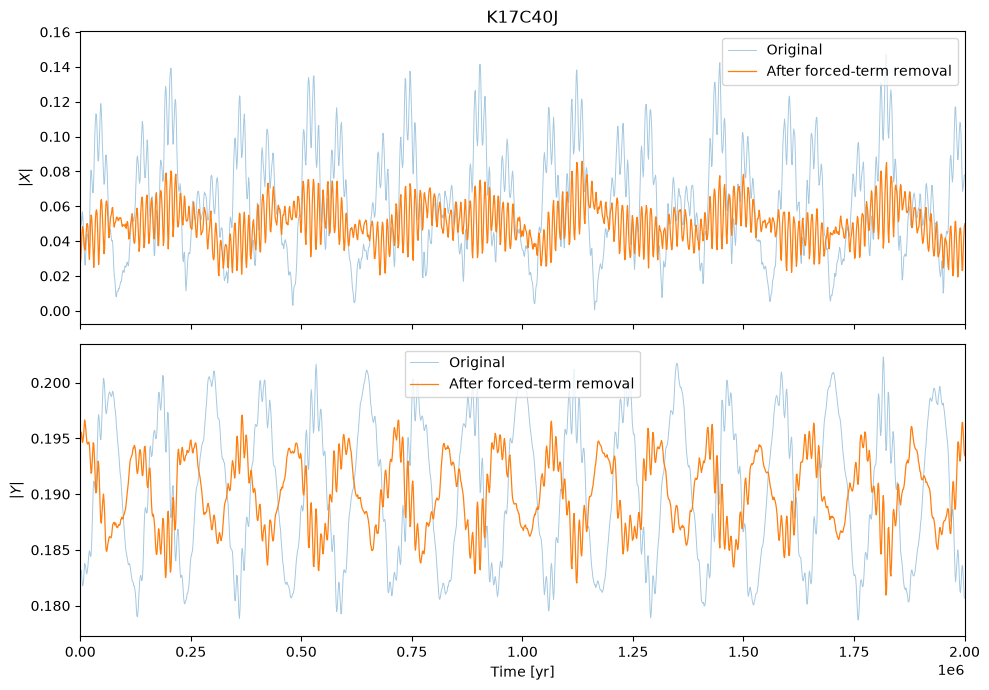

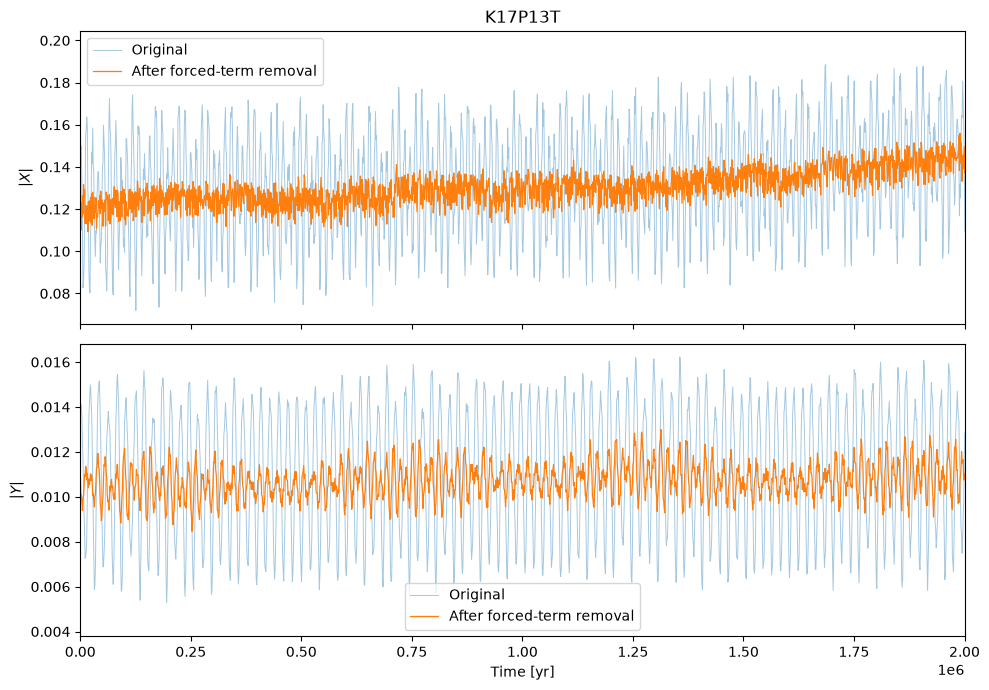

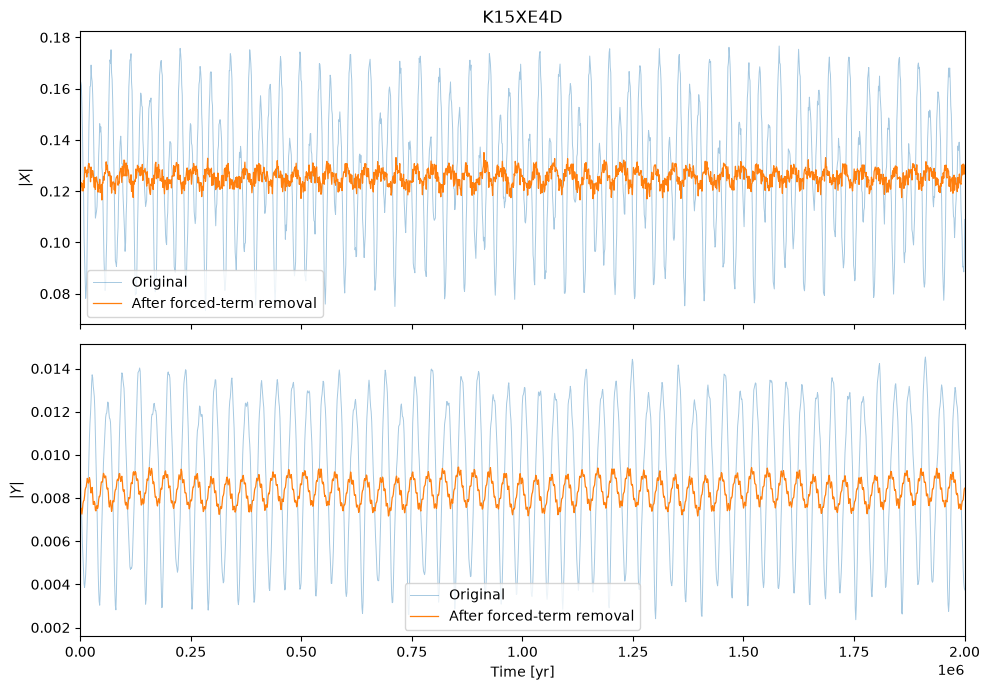

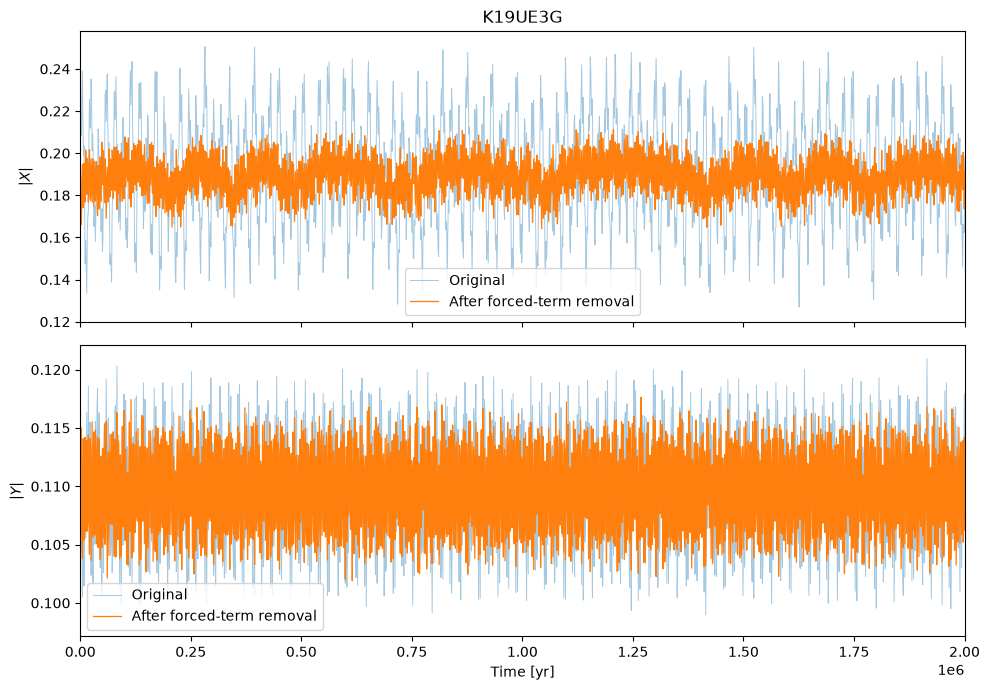

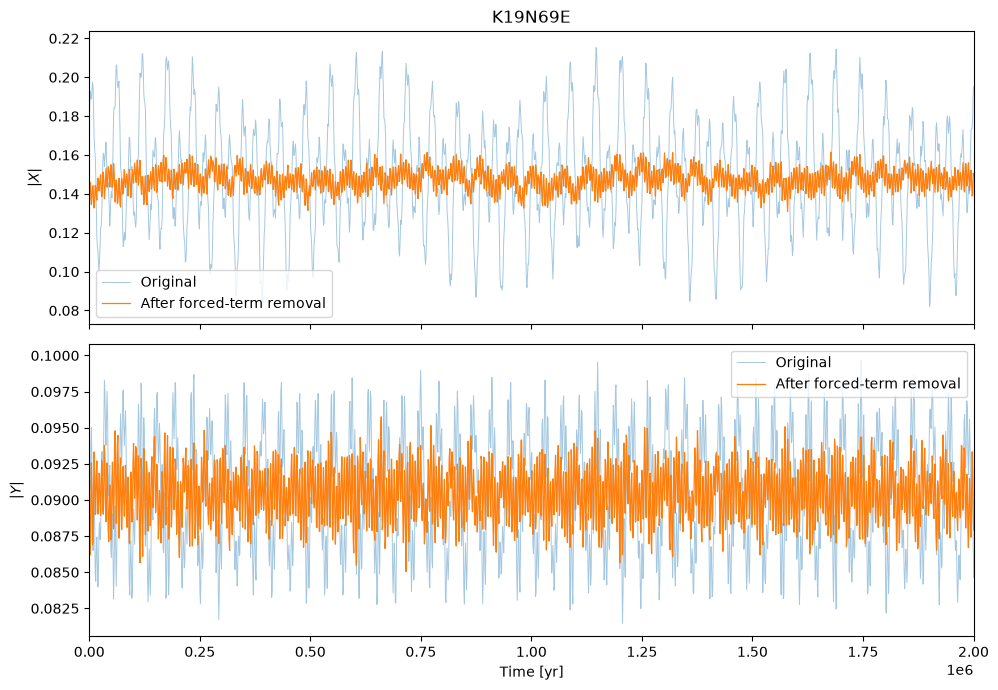

In [15]:
proper_results = {}

for asteroid in asteroids:
    i_ast = planets.index(asteroid)
    t = results["time"]
    t_yr = t/(2*np.pi)

    # Eccentricity
    x_dict = x_dicts[i_ast]
    X_forced = np.zeros_like(results["X"][i_ast], dtype=complex)

    for k_tuple, amp in x_dict.items():
        k = np.array(k_tuple)
        omega = k @ omega_vec
        X_forced += amp*np.exp(1j*omega*t)

    X_actual = results["X"][i_ast]
    X_free = X_actual - X_forced

    X_free_fmft = fmft(t, X_free, 20)
    g_free, X_amp = max(X_free_fmft.items(), key=lambda x: np.abs(x[1]))
    A_X = np.abs(X_amp)

    e_proper = np.sqrt(np.clip(1-(1-A_X**2/2)**2, 0, 1))

    # Inclination
    y_dict = y_dicts[i_ast]
    Y_forced = np.zeros_like(results["Y"][i_ast], dtype=complex)

    for k_tuple, amp in y_dict.items():
        k = np.array(k_tuple)
        omega = k @ omega_vec
        Y_forced += amp*np.exp(1j*omega*t)

    Y_actual = results["Y"][i_ast]
    Y_free = Y_actual - Y_forced

    Y_free_fmft = fmft(t, Y_free, 20)
    s_free, Y_amp = max(Y_free_fmft.items(), key=lambda x: np.abs(x[1]))
    A_Y = np.abs(Y_amp)

    sin_half_i = np.clip(A_Y/(1-e_proper**2)**0.25, 0, 1)
    i_proper = 2*np.arcsin(sin_half_i)
    sini_proper = np.sin(i_proper)

    # Save results
    proper_results[asteroid] = {
        "Des'n": asteroid,
        "e_proper": e_proper,
        "i_proper_rad": i_proper,
        "sini_proper": sini_proper,
        "X_amp": A_X,
        "Y_amp": A_Y
    }

    # Plot
    fig, ax = plt.subplots(2, 1, figsize=(10,7), sharex=True)

    ax[0].plot(t_yr, np.abs(X_actual), lw=0.7, alpha=0.4, label="Original")
    ax[0].plot(t_yr, np.abs(X_free), lw=0.9, label="After forced-term removal")
    ax[0].set_ylabel(r"$|X|$")
    ax[0].set_title(fr"{asteroid}")
    ax[0].legend()

    ax[1].plot(t_yr, np.abs(Y_actual), lw=0.7, alpha=0.4, label="Original")
    ax[1].plot(t_yr, np.abs(Y_free), lw=0.9, label="After forced-term removal")
    ax[1].set_ylabel(r"$|Y|$")
    ax[1].set_xlabel("Time [yr]")
    ax[1].set_xlim(0, 0.2*1e7)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [16]:
df_compare = df_xgb[
    df_xgb["Des'n"].isin(asteroids)
][["Des'n", "prope", "prope_h", "propsini", "propsini_h"]].copy()

df_compare["prope_int"] = df_compare["Des'n"].map(
    lambda x: proper_results[x]["e_proper"]
)

df_compare["propsini_int"] = df_compare["Des'n"].map(
    lambda x: proper_results[x]["sini_proper"]
)

In [17]:
from linear_theory import linear_theory_prediction, make_simpler_secular_theory
# Lists to store calculated linear estimate of proper orbital elements
u0_list = []
v0_list = []
g0_list = []
s0_list = []

# Load files for linear theory
simpler_secular_theory = make_simpler_secular_theory()

# Calculate linear estimate for each candidate asteroid
for i,row in df_orbits.iterrows():
	u0, v0, g0, s0 = linear_theory_prediction(row['e'], row['Incl.'] * np.pi / 180, row['Peri.'] * np.pi / 180, row['Node'] * np.pi / 180, row['a'], simpler_secular_theory)
	u0_list.append(u0)
	v0_list.append(v0)
	g0_list.append(g0)
	s0_list.append(s0)

df_compare['prope_h']    = [np.abs(complex(x)) for x in u0_list]
df_compare['propsini_h'] = [np.sin(np.abs(complex(x))) for x in v0_list]


df_compare = df_compare[["Des'n", "prope", "prope_int", "prope_h", "propsini", "propsini_int", "propsini_h"]]

In [18]:
df_compare["label"] = np.select(
    [
        df_compare["Des'n"].isin(asteroids_good),
        df_compare["Des'n"].isin(asteroids_bad),
    ],
    [
        "good linear prediction",
        "bad linear prediction",
    ],
    default=""
)

In [20]:
df_compare.to_csv("data/linear_rebound_comparison_real.csv")
df_compare

,Des'n,prope,prope_int,prope_h,propsini,propsini_int,propsini_h,label
1,K17C40J,0.030484,0.048051,0.088070,0.374051,0.371889,0.385722,bad linear prediction
41,K17P13T,0.117180,0.090750,0.180469,0.020715,0.011263,0.012959,bad linear prediction
71,K15XE4D,0.126495,0.124814,0.196064,0.017113,0.016636,0.024734,bad linear prediction
73,K19UE3G,0.187963,0.185492,0.179638,0.219899,0.218337,0.197280,good linear prediction
78,K19N69E,0.151750,0.146781,0.145785,0.181199,0.178491,0.161644,good linear prediction
